<a href="https://colab.research.google.com/github/GloryValentio/Breast_Cancer/blob/main/breast_cancer/DTBreast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/GloryValentio/Breast_Cancer.git

Cloning into 'Breast_Cancer'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
#untuk menghubungkan goggle colab dan goggle drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DT_TASK/breast-cancer.csv')

# Fitur (X) dan label (y)
X = df.iloc[:, : -1].values
y = df.iloc[:, -1].values

# Nama fitur (semua kolom kecuali label)
feature_names = df.columns[:-1].tolist()

# Nama kelas (label unik)
class_names = sorted(df.iloc[:, -1].unique().astype(str))


In [ ]:
df.head

<bound method NDFrame.head of      radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0             0.27760         0.30010              0.14710         0.2419   
1             0.07864         0.08690              0.07017         0.1812   
2             0.15990         0.19740              0.12790         0.2069   
3             0.28390         0.24140              0.10520         0.2597   
4             0.13280         0.19800              0.10430         0.1809   
..                ...             ...                  ...            ...   
564           0.11590         0.24390              0.13890         0.1726   
565           0.10340         0.14400              0.09791         0.1752   
566           0.10230         0.09251              0.05302         0.1590   
567           0.27700         0.35140              0.15200         0.2397   
568           0.04362         0.00000              0.00000         0.1587   

     fractal dimension_mean  ...  texture_worst  perimeter_worst  area_worst  \
0                   0.07871  ...          17.33           184.60      2019.0   
1                   0.05667  ...          23.41           158.80      1956.0   
2                   0.05999  ...          25.53           152.50      1709.0   
3                   0.09744  ...          26.50            98.87       567.7   
4                   0.05883  ...          16.67           152.20      1575.0   
..                      ...  ...            ...              ...         ...   
564                 0.05623  ...          26.40           166.10      2027.0   
565                 0.05533  ...          38.25           155.00      1731.0   
566                 0.05648  ...          34.12           126.70      1124.0   
567                 0.07016  ...          39.42           184.60      1821.0   
568                 0.05884  ...          30.37            59.16       268.6   

     smoothness_worst  compactness_worst  concavity_worst  \
0             0.16220            0.66560           0.7119   
1             0.12380            0.18660           0.2416   
2             0.14440            0.42450           0.4504   
3             0.20980            0.86630           0.6869   
4             0.13740            0.20500           0.4000   
..                ...                ...              ...   
564           0.14100            0.21130           0.4107   
565           0.11660            0.19220           0.3215   
566           0.11390            0.30940           0.3403   
567           0.16500            0.86810           0.9387   
568           0.08996            0.06444           0.0000   

     concave points_worst  symmetry_worst  fractal dimension_worst  label  
0                  0.2654          0.4601                  0.11890      M  
1                  0.1860          0.2750                  0.08902      M  
2                  0.2430          0.3613                  0.08758      M  
3                  0.2575          0.6638                  0.17300      M  
4                  0.1625         

In [ ]:
print(len(df))
df.head()

569


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal dimension_worst,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [ ]:
df.dtypes

,0
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64
symmetry_mean,float64
fractal dimension_mean,float64


In [ ]:
# Membagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=70,
    stratify=y
)

print("Data Latih",len(X_train))
print("Data Uji",len(X_test))

Data Latih 455
Data Uji 114


In [ ]:
# Membuat model Decision Tree
dt_model = DecisionTreeClassifier(
  criterion="log_loss",
  max_depth=3,
  random_state=70
)

# Training model
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(criterion='log_loss', max_depth=3, random_state=70)

In [ ]:
# Evaluasi sederhana pada data test
accuracy = dt_model.score(X_test, y_test)
print(f"Akurasi pada data test: {accuracy:.2f}")


Akurasi pada data test: 0.96


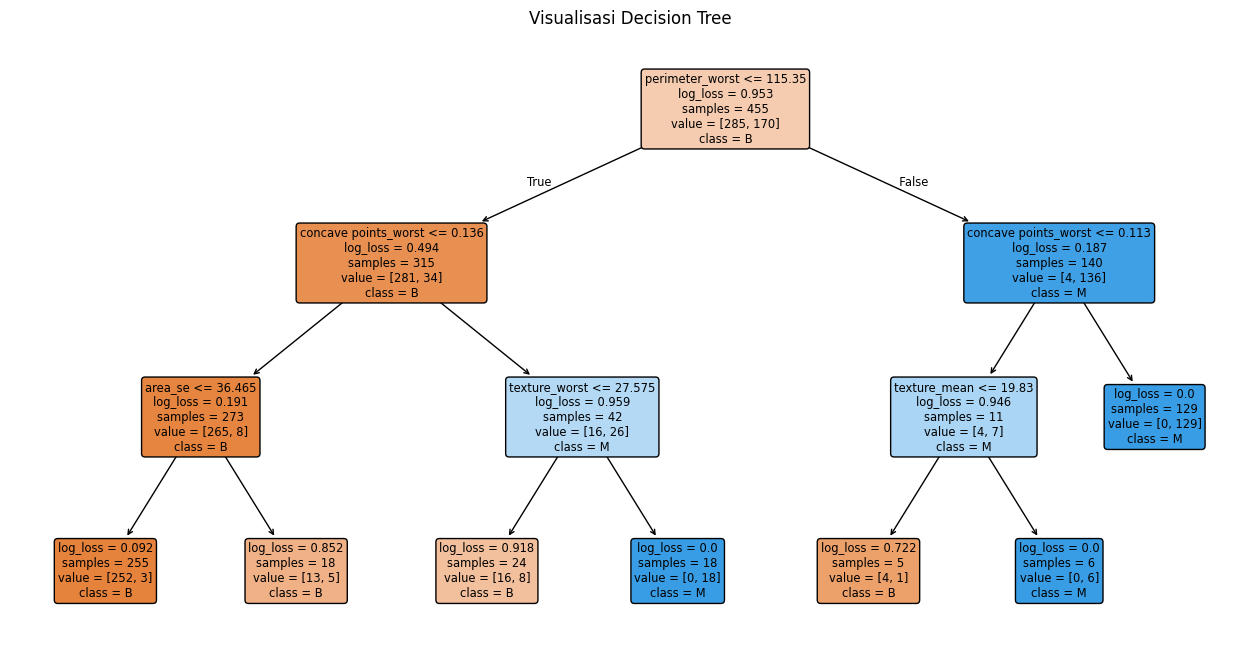

In [ ]:
# Menampilkan visualisasi decision tree
plt.figure(figsize=(16, 8))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True
)
plt.title("Visualisasi Decision Tree")
plt.show()


In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, dt_model.predict(X_test))
print(cm)

[[72  0]
 [ 5 37]]


In [ ]:
print('Training set score: {:.4f}'.format(dt_model.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(dt_model.score(X_test, y_test)))

Training set score: 0.9626
Test set score: 0.9561


In [ ]:
import joblib
joblib.dump(dt_model, '/content/drive/MyDrive/DT_TASK.pkl')

['/content/drive/MyDrive/DT_TASK.pkl']

In [ ]:
import joblib
loaded_model = joblib.load('/content/drive/MyDrive/DT_TASK/DT_TASK.pkl')

pred_class = loaded_model.predict(X_test)[0]

In [ ]:
# Menelusuri jejak keputusan pada decision tree
def trace_decision_path(model, x, feature_names):
    """
    Menampilkan jalur keputusan (rule-by-rule) dari Decision Tree
    """
    node_indicator = model.decision_path(x)
    leaf_id = model.apply(x)

    print("Tracing decision path:\n")

    for node_id in node_indicator.indices:
        # Jika node adalah leaf, berhenti
        if leaf_id[0] == node_id:
            print(f"Reached leaf node {node_id}")
            break

        feature = model.tree_.feature[node_id]
        threshold = model.tree_.threshold[node_id]

        if x[0, feature] <= threshold:
            decision = "<="
        else:
            decision = ">"

        print(
            f"Node {node_id}: "
            f"{feature_names[feature]} {decision} {threshold:.2f}"
        )

trace_decision_path(loaded_model, X_test[0:1], feature_names)


Tracing decision path:

Node 0: perimeter_worst <= 114.45
Node 1: concave points_worst <= 0.11
Reached leaf node 2


In [ ]:
from sklearn.metrics import classification_report

y_pred = dt_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.94      1.00      0.97        72
           M       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

